In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sb

In [15]:
non_outlier_df = pd.read_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\non_outlier_df.csv")

In [16]:
scaled_df = pd.read_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\scaled_data_df.csv")

In [17]:
scaled_df.head(5)

,Monetary_value,Frequency,Recency
0,-0.880837,-0.383704,0.683417
1,0.271223,-0.383704,-0.967780
2,-0.772835,-0.831675,-0.244107
3,1.642986,-0.383704,-0.560077
4,-0.661150,-0.831675,-0.886239


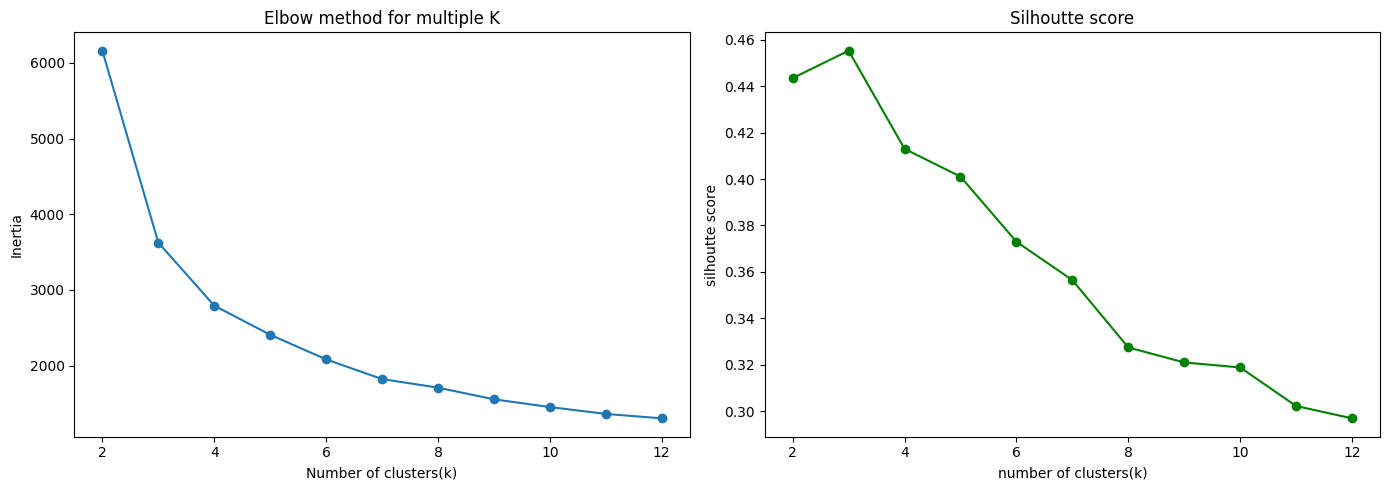

In [18]:
# Find the cluster(k-number) using elbow method / silhoutte score

inertia = []
sil_scores = []
k_range = range(2,13) 

for k in k_range:
    kmeans = KMeans(n_clusters=k,random_state=42,max_iter=1000)
    cluster_label = kmeans.fit_predict(scaled_df)
    inertia.append(kmeans.inertia_)
    sil_score = silhouette_score(scaled_df,cluster_label)
    sil_scores.append(sil_score)

fig, ax = plt.subplots(1,2,figsize=(14,5))
ax[0].plot(k_range,inertia,marker="o")
ax[0].set_title("Elbow method for multiple K")
ax[0].set_xlabel("Number of clusters(k)")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_range,sil_scores,marker="o",color="green")
ax[1].set_title("Silhoutte score")
ax[1].set_xlabel("number of clusters(k)")
ax[1].set_ylabel("silhoutte score")

plt.tight_layout()
plt.show()

 # interpretation for finding cluster k number
 
 - k = 3 indicate the best k number as it show biggest bend in  elbow and the highest silhoutte score 
 - But K = 3 provide less insight 
 - we choose k = 4 because as it next stable point and second highest silhoutte score 

In [22]:
# Input the k=4 into the kmeans and run the model
k = 4
kmeans = KMeans(n_clusters=4,random_state=10,max_iter=1000,n_init=10)
non_outlier_df["Cluster"] = kmeans.fit_predict(scaled_df)
non_outlier_df

,Customer ID,Country,Total_sales,Frequency,LastInvoiceDate,Reference_date,Recency,Cluster
0,12346.0,United Kingdom,144.02,2,2010-06-28 13:53:00,2010-12-09 20:01:00,164,2
1,12347.0,Iceland,966.87,2,2010-12-07 14:57:00,2010-12-09 20:01:00,2,0
2,12348.0,Finland,221.16,1,2010-09-27 14:59:00,2010-12-09 20:01:00,73,0
3,12349.0,Italy,1946.64,2,2010-10-28 08:23:00,2010-12-09 20:01:00,42,3
4,12351.0,Unspecified,300.93,1,2010-11-29 15:23:00,2010-12-09 20:01:00,10,0
...,...,...,...,...,...,...,...,...
3780,18283.0,United Kingdom,563.19,6,2010-11-22 15:30:00,2010-12-09 20:01:00,17,3
3781,18284.0,United Kingdom,391.28,1,2010-10-04 11:33:00,2010-12-09 20:01:00,66,0
3782,18285.0,United Kingdom,361.10,1,2010-02-17 10:24:00,2010-12-09 20:01:00,295,2
3783,18286.0,United Kingdom,948.30,2,2010-08-20 11:57:00,2010-12-09 20:01:00,111,0


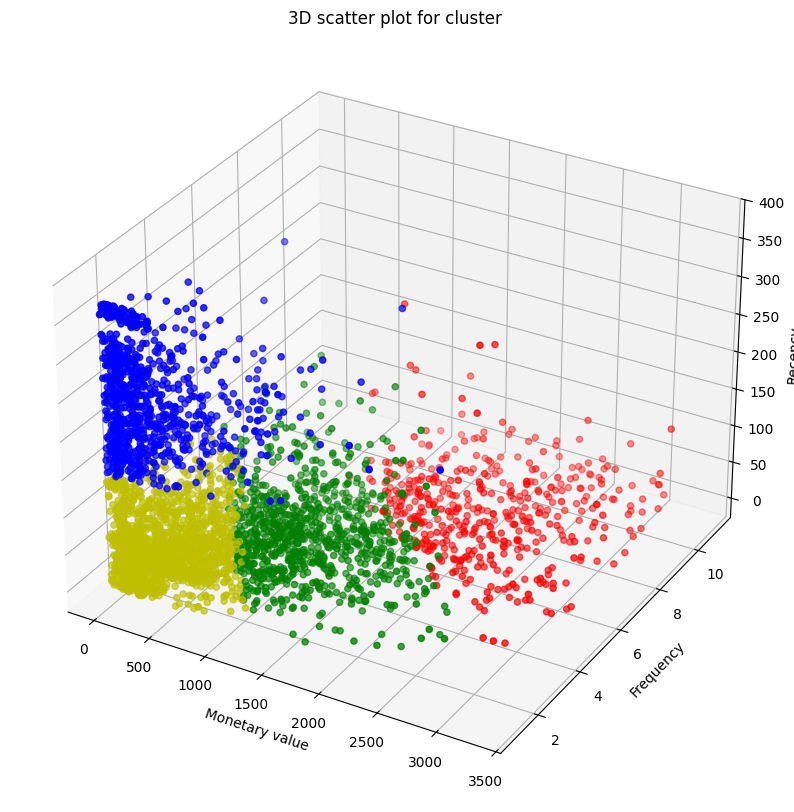

In [21]:
# Visualised the cluster with 3d scatter plot

cluster_colours = {
    0: "y",
    1: "r",
    2: "b",
    3: "g"
}

colors = non_outlier_df["Cluster"].map(cluster_colours)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(non_outlier_df["Total_sales"], non_outlier_df["Frequency"],non_outlier_df["Recency"], c=colors,marker="o")
ax.set_title("3D scatter plot for cluster")
ax.set_xlabel("Monetary value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
plt.show()


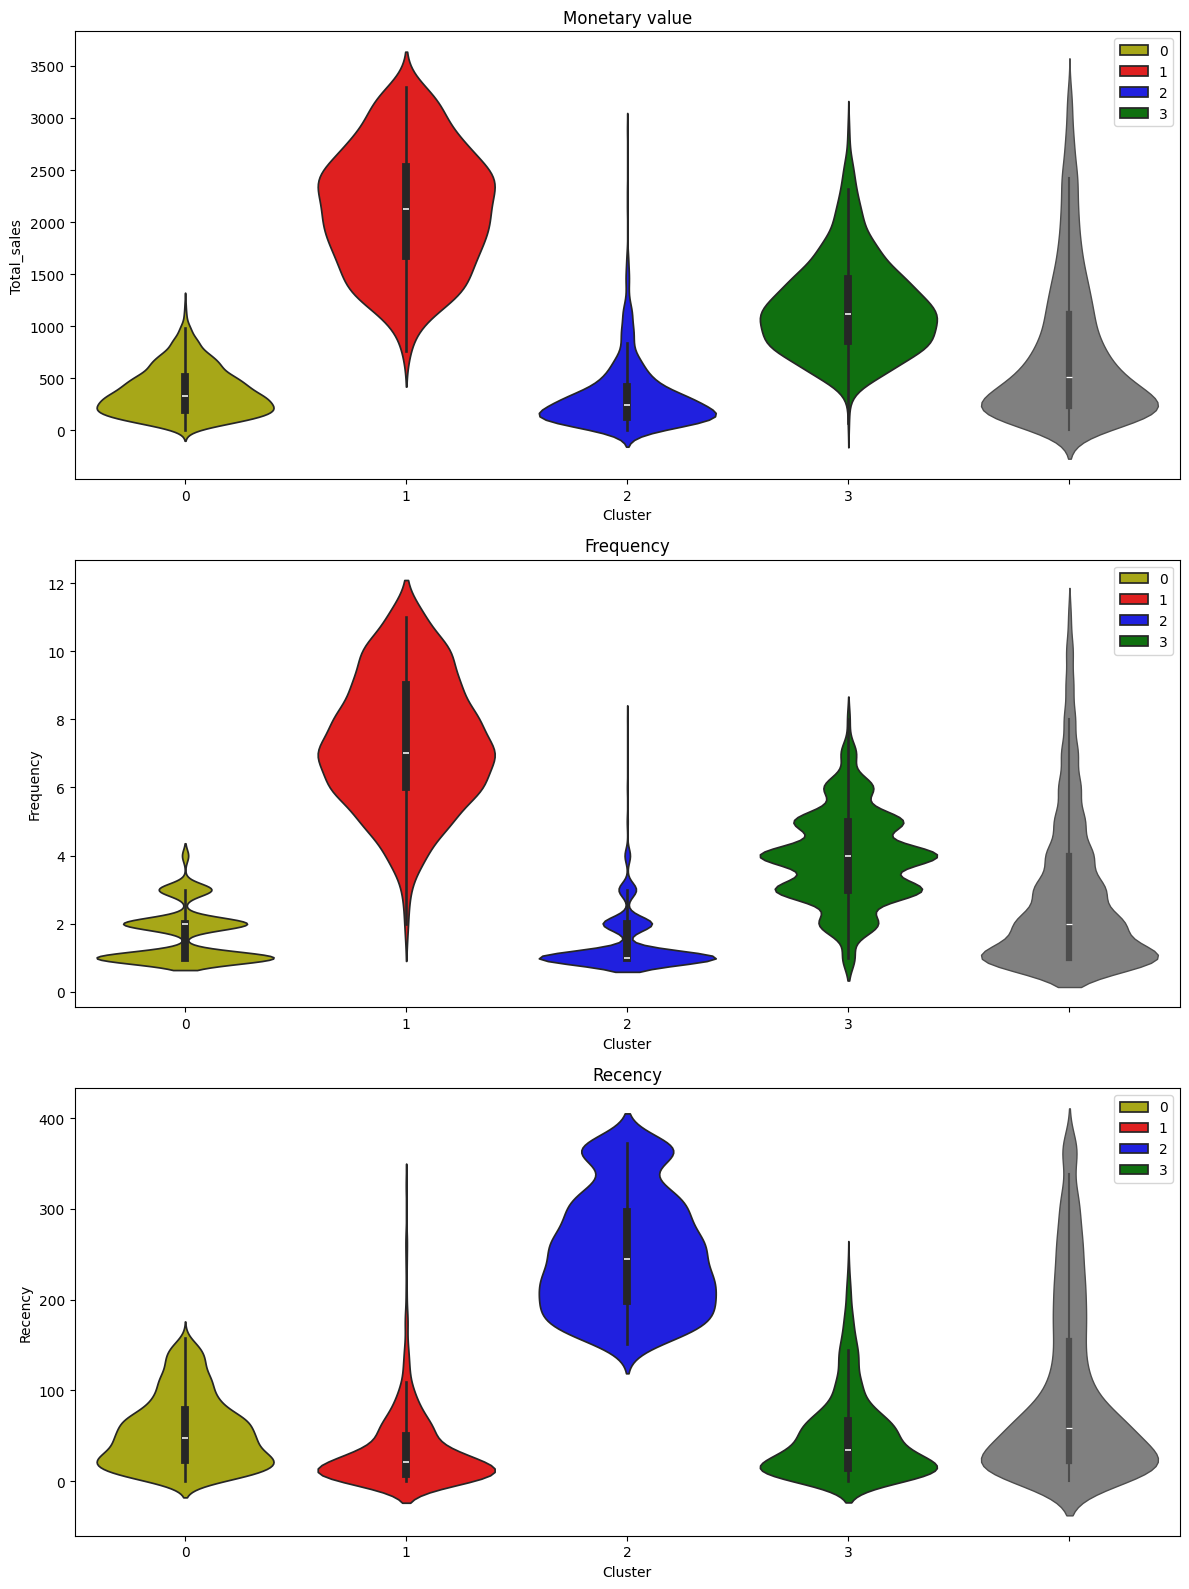

In [27]:
# Visualise each cluster's distribution using violin plot 
# Understanding cluster distribution help in indentify clsuter label 

plt.figure(figsize=(12,16))
plt.subplot(3,1,1)
sb.violinplot(x=non_outlier_df["Cluster"],y=non_outlier_df["Total_sales"],palette=cluster_colours,hue=non_outlier_df["Cluster"])
sb.violinplot(y=non_outlier_df["Total_sales"],color="grey",linewidth=1.0) # this is the reference monetary value for all customer without grouping by cluster
plt.title("Monetary value")

plt.subplot(3,1,2)
sb.violinplot(x=non_outlier_df["Cluster"],y=non_outlier_df["Frequency"],palette=cluster_colours,hue=non_outlier_df["Cluster"])
sb.violinplot(y=non_outlier_df["Frequency"],color="grey",linewidth=1.0) # this is the reference frequency for all customer without grouping by cluster
plt.title("Frequency")

plt.subplot(3,1,3)
sb.violinplot(x=non_outlier_df["Cluster"],y=non_outlier_df["Recency"],palette=cluster_colours,hue=non_outlier_df["Cluster"])
sb.violinplot(y=non_outlier_df["Recency"],color="grey",linewidth=1.0) # this is the reference recency for all customer without grouping by cluster
plt.title("Recency")

plt.tight_layout()
plt.show()

# Interpretation of Violinplot 

1. Cluster 0 (yellow) = low monetary value , low frequency , low recency which indicate inactive low value new customer or re-entry customer with recent purchase (New customer/Inactive customer)
- Solution: FOcus on building relationship with these group of customer and provide good customer service with provide incentive to encourage more frequent purchase. n

2. Cluster 1 (red)    = high monetary value, high frequency, low recency which indicate active high value customer with recent purchase (VIP customer)
- Solution: Reward program for loyalty customer 

3. Cluster 2 (blue)   = low monetary value, very low frequency, high recency which indicate dormant low value customer with no recent purchase (dormant customer)
- Solution: Re-engage program 

4. Cluster 3 (green)  = high monetary value, moderate freqeuncy, high recency which indicate active high value customer with no recent purchase (key customer)
- Solution: Personalized offer and loyalty program 